In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [10]:
df = pd.read_csv(
    "../data/processed/lending_club_clean.csv",
    parse_dates=[
        "issue_d",
        "earliest_cr_line"
    ]
)

print(df.shape)

df.head()

(2260638, 36)


,loan_amnt,term,int_rate,installment,grade,sub_grade,loan_status,purpose,issue_d,annual_inc,emp_length,home_ownership,verification_status,fico_range_low,fico_range_high,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,delinq_2yrs,inq_last_6mths,earliest_cr_line,mort_acc,tot_cur_bal,total_bc_limit,tot_hi_cred_lim,addr_state,application_type,default_flag,credit_score,income_group,loan_amount_group,interest_rate_group,issue_year
0,3600.0,36.0,13.99,123.03,C,C4,Fully Paid,debt_consolidation,2015-12-01,55000.0,10+ years,MORTGAGE,Not Verified,675.0,679.0,5.91,7.0,0.0,2765.0,29.7,13.0,0.0,1.0,2003-08-01,1.0,144904.0,2400.0,178050.0,PA,Individual,0,677.0,Middle,Small,High,2015
1,24700.0,36.0,11.99,820.28,C,C1,Fully Paid,small_business,2015-12-01,65000.0,10+ years,MORTGAGE,Not Verified,715.0,719.0,16.06,22.0,0.0,21470.0,19.2,38.0,1.0,4.0,1999-12-01,4.0,204396.0,79300.0,314017.0,SD,Individual,0,717.0,Middle,Large,Moderate,2015
2,20000.0,60.0,10.78,432.66,B,B4,Fully Paid,home_improvement,2015-12-01,63000.0,10+ years,MORTGAGE,Not Verified,695.0,699.0,10.78,6.0,0.0,7869.0,56.2,18.0,0.0,0.0,2000-08-01,5.0,189699.0,6200.0,218418.0,IL,Joint App,0,697.0,Middle,Large,Moderate,2015
3,35000.0,60.0,14.85,829.90,C,C5,Current,debt_consolidation,2015-12-01,110000.0,10+ years,MORTGAGE,Source Verified,785.0,789.0,17.06,13.0,0.0,7802.0,11.6,17.0,0.0,0.0,2008-09-01,1.0,301500.0,62500.0,381215.0,NJ,Individual,0,787.0,High,Very Large,High,2015
4,10400.0,60.0,22.45,289.91,F,F1,Fully Paid,major_purchase,2015-12-01,104433.0,3 years,MORTGAGE,Source Verified,695.0,699.0,25.37,12.0,0.0,21929.0,64.5,35.0,1.0,3.0,1998-06-01,6.0,331730.0,20300.0,439570.0,PA,Individual,0,697.0,High,Medium,Very High,2015


In [11]:
print("=" * 60)
print("BANK LOAN DATASET OVERVIEW")
print("=" * 60)

print(f"Rows : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print(f"Missing Values : {df.isnull().sum().sum()}")

BANK LOAN DATASET OVERVIEW
Rows : 2,260,638
Columns : 36
Duplicate Rows : 0
Missing Values : 1667


 # Portfolio Overview

In [12]:
total_loans = len(df)

total_loan_amount = df["loan_amnt"].sum()

avg_loan = df["loan_amnt"].mean()

avg_interest = df["int_rate"].mean()

default_rate = (
    df["default_flag"].mean() * 100
)

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Loans",
        "Total Loan Amount",
        "Average Loan Amount",
        "Average Interest Rate",
        "Default Rate (%)"
    ],
    "Value": [
        f"{total_loans:,}",
        f"${total_loan_amount:,.0f}",
        f"${avg_loan:,.2f}",
        f"{avg_interest:.2f}%",
        f"{default_rate:.2f}%"
    ]
})

portfolio_summary


,Metric,Value
0,Total Loans,"2,260,638"
1,Total Loan Amount,"$34,015,967,725"
2,Average Loan Amount,"$15,047.07"
3,Average Interest Rate,13.09%
4,Default Rate (%),13.02%


In [16]:
status_order = [
    "Fully Paid",
    "Current",
    "Charged Off",
    "Late (31-120 days)",
    "Late (16-30 days)",
    "In Grace Period",
    "Default",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
]

loan_status = (
    df["loan_status"]
    .value_counts()
    .reindex(status_order)
    .fillna(0)
)

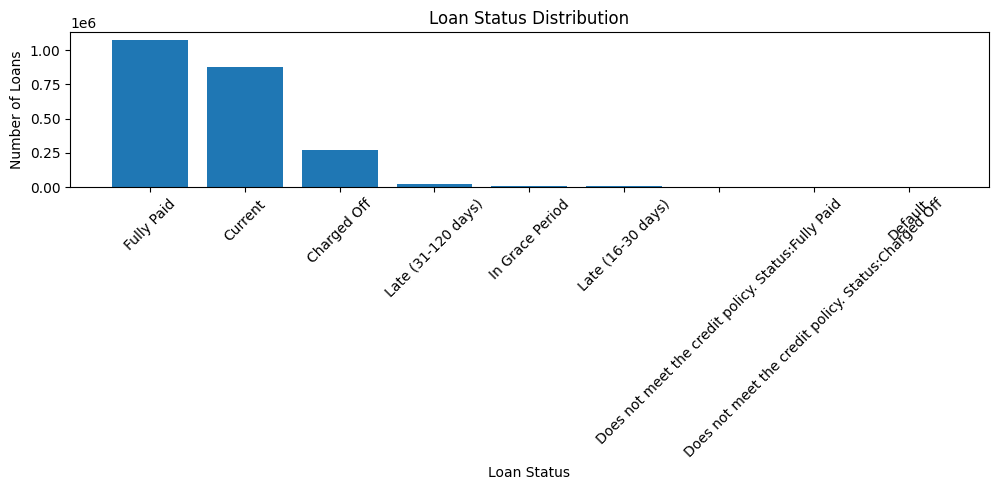

In [19]:
loan_status = df["loan_status"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(loan_status.index, loan_status.values)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../assets/python/loan_status_distribution.png",
    dpi=300
)

plt.show()

### Business Question

How are loans distributed across different loan statuses?

### Observation

- Fully Paid loans represent the largest share of the portfolio.
- Current loans are the second-largest category.
- Charged Off loans form a noticeable portion of the portfolio.
- Default and late-payment categories are relatively small.

### Business Insight

The portfolio is dominated by performing loans, indicating overall healthy lending performance. However, the number of Charged Off loans highlights the importance of effective credit risk assessment and borrower screening.

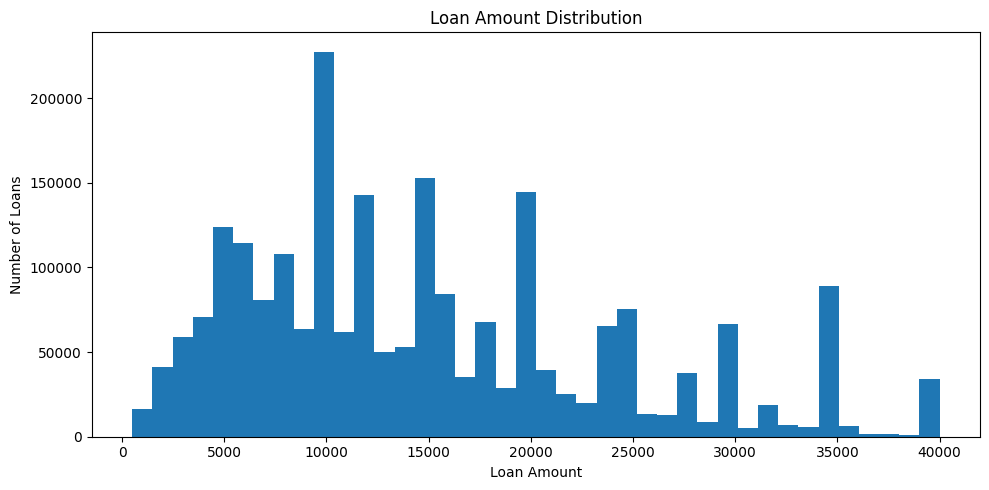

In [20]:
plt.figure(figsize=(10,5))

plt.hist(
    df["loan_amnt"],
    bins=40
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "../assets/python/loan_amount_distribution.png",
    dpi=300
)

plt.show()

Observation

* Most loans fall within lower loan amount ranges.
* High-value loans are relatively uncommon.

Business Insight

The lending portfolio primarily consists of small to medium-sized loans, reducing exposure to individual large-loan risk.

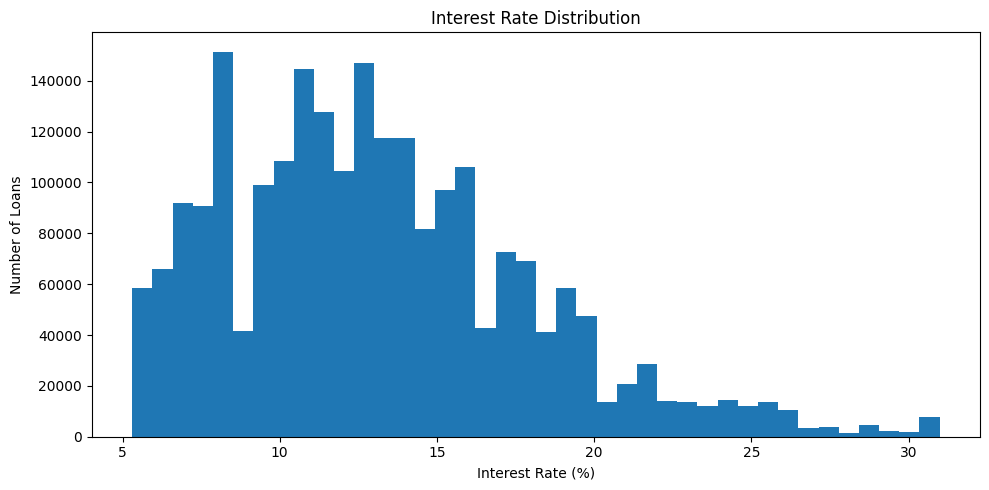

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    df["int_rate"],
    bins=40
)

plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "../assets/python/interest_rate_distribution.png",
    dpi=300
)

plt.show()

Observation

* Interest rates are concentrated within a moderate range.
* Very high interest rates are less common.

Business Insight

Most borrowers receive moderate interest rates, indicating balanced credit underwriting.


# Customer Analysis

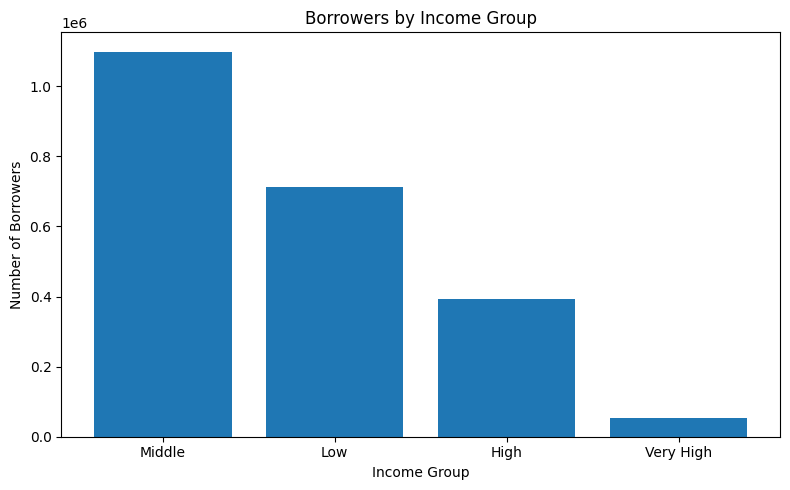

In [22]:
income = (
    df["income_group"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    income.index,
    income.values
)

plt.title("Borrowers by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Borrowers")

plt.tight_layout()

plt.savefig(
    "../assets/python/income_group_distribution.png",
    dpi=300
)

plt.show()

Observation

* Middle-income borrowers account for the largest share.
* Very high-income borrowers form the smallest segment.

Business Insight

The bank’s lending strategy primarily targets middle-income customers, who represent the core customer base.

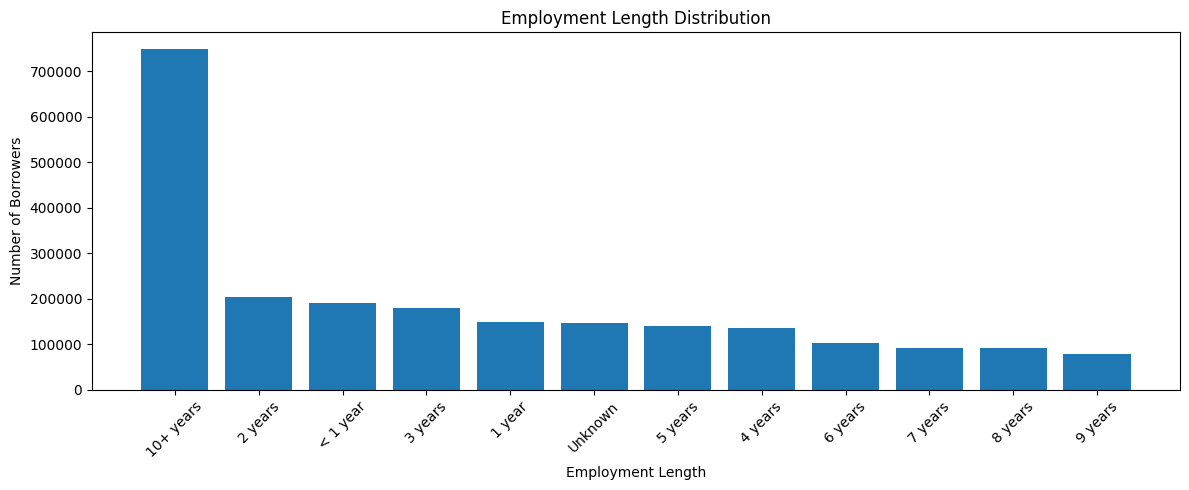

In [23]:
employment = (
    df["emp_length"]
    .value_counts()
)

plt.figure(figsize=(12,5))

plt.bar(
    employment.index.astype(str),
    employment.values
)

plt.title("Employment Length Distribution")
plt.xlabel("Employment Length")
plt.ylabel("Number of Borrowers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../assets/python/employment_length_distribution.png",
    dpi=300
)

plt.show()

Observation

* Borrowers with longer employment histories form a significant portion of the portfolio.
* Unknown employment records are relatively few.

Business Insight

Employment stability appears to be a common characteristic among borrowers and may be associated with lower lending risk.

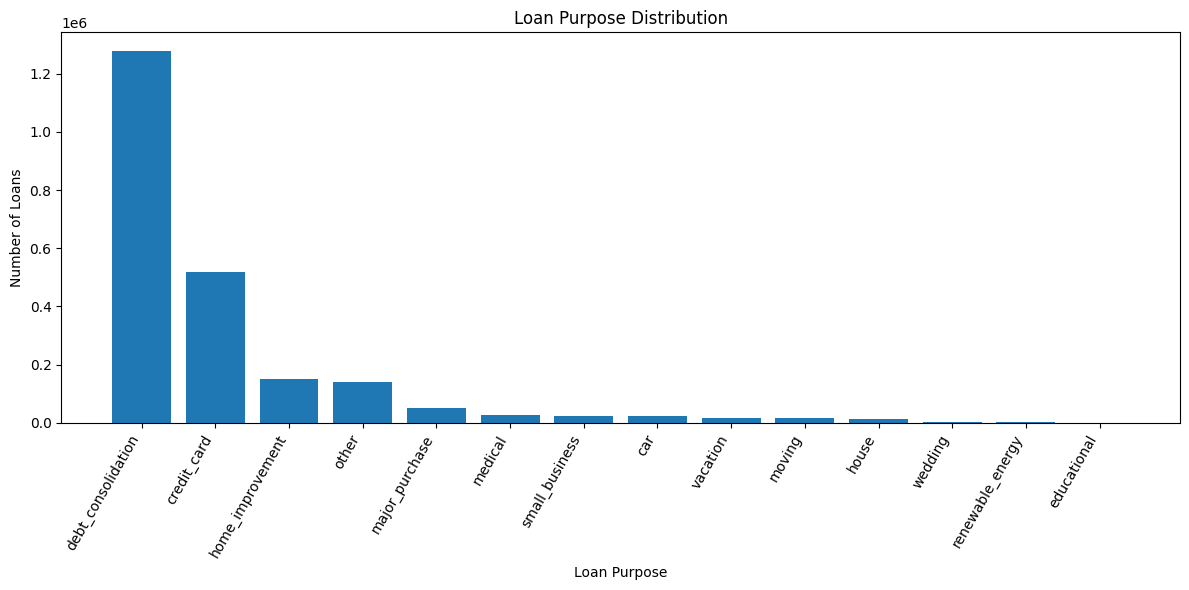

In [25]:
purpose = (
    df["purpose"]
    .value_counts()
)

plt.figure(figsize=(12,6))

plt.bar(
    purpose.index,
    purpose.values
)

plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Loans")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig(
    "../assets/python/loan_purpose_distribution.png",
    dpi=300
)

plt.show()

Observation

* Debt consolidation is expected to be the most common loan purpose.
* Credit card refinancing and home improvement are also popular.

Business Insight

Understanding loan purposes helps identify which financial needs drive borrowing and where default monitoring should be focused.

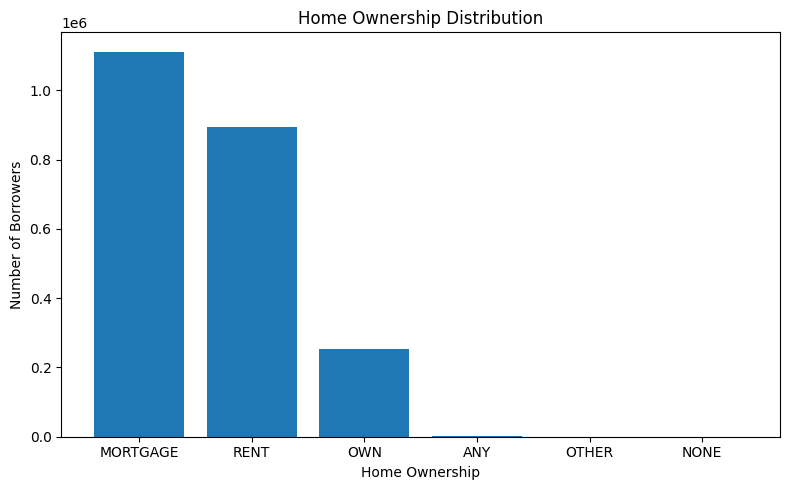

In [26]:
ownership = (
    df["home_ownership"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    ownership.index,
    ownership.values
)

plt.title("Home Ownership Distribution")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Borrowers")

plt.tight_layout()

plt.savefig(
    "../assets/python/home_ownership_distribution.png",
    dpi=300
)

plt.show()

Observation

* Mortgage and Rent categories dominate the portfolio.
* Home ownership varies across borrowers.

Business Insight

Housing status provides useful context when evaluating borrower financial stability.

# Risk Analysis

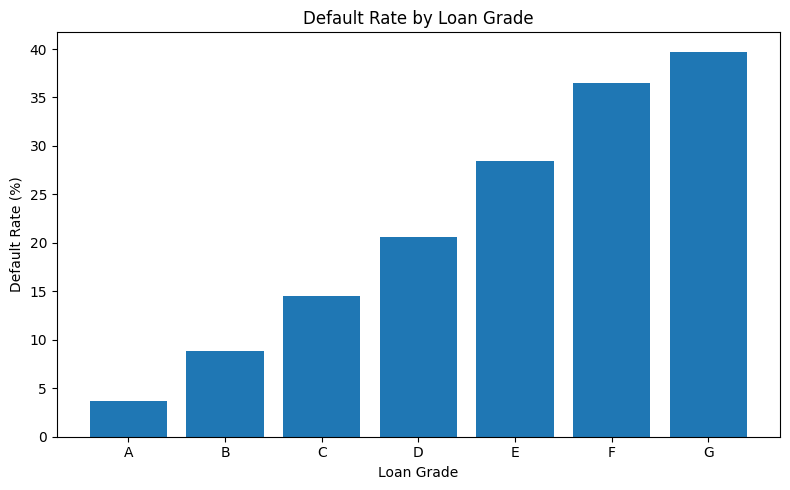

In [27]:
grade_default = (
    df.groupby("grade")["default_flag"]
    .mean()
    .sort_index() * 100
)

plt.figure(figsize=(8,5))

plt.bar(
    grade_default.index,
    grade_default.values
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "../assets/python/default_by_grade.png",
    dpi=300
)

plt.show()

Observation

* Default rates increase as loan grade declines.
* Lower-quality grades carry significantly higher risk.

Business Insight

Loan grade is one of the strongest indicators of credit risk and should be closely monitored.

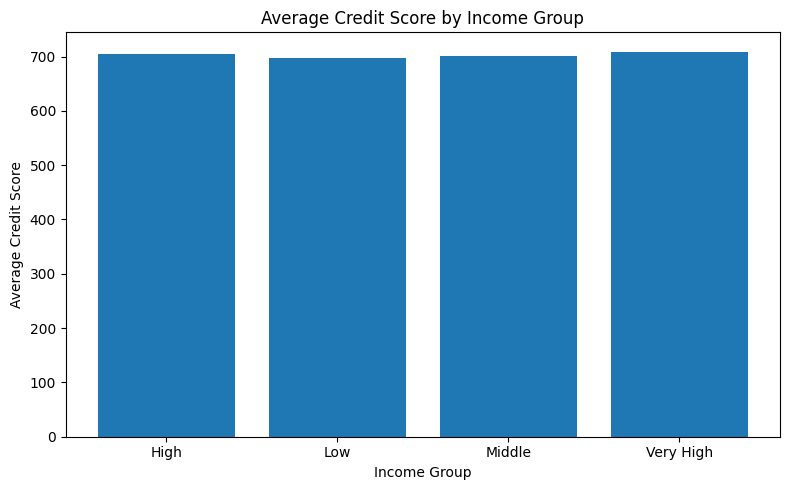

In [28]:
credit_default = (
    df.groupby("income_group")["credit_score"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.bar(
    credit_default.index.astype(str),
    credit_default.values
)

plt.title("Average Credit Score by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Credit Score")

plt.tight_layout()

plt.savefig(
    "../assets/python/credit_score_by_income.png",
    dpi=300
)

plt.show()

Observation

* Credit scores generally improve with higher income groups.
* Lower-income borrowers tend to have lower average credit scores.

Business Insight

Income and credit quality appear to be positively related, providing additional context for borrower risk assessment.

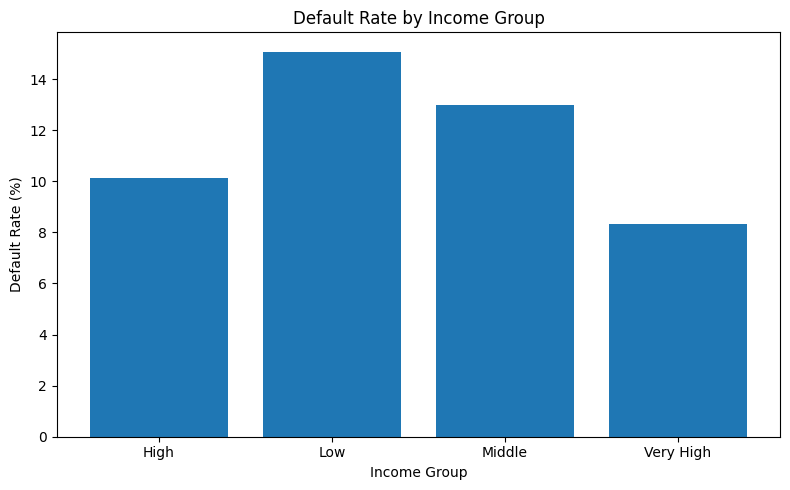

In [29]:
income_default = (
    df.groupby("income_group")["default_flag"]
    .mean() * 100
)

plt.figure(figsize=(8,5))

plt.bar(
    income_default.index.astype(str),
    income_default.values
)

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "../assets/python/default_by_income_group.png",
    dpi=300
)

plt.show()

Observation

* Default rates vary across income groups.
* Lower-income borrowers generally show higher default rates.

Business Insight

Income level is an important factor when assessing borrower risk.

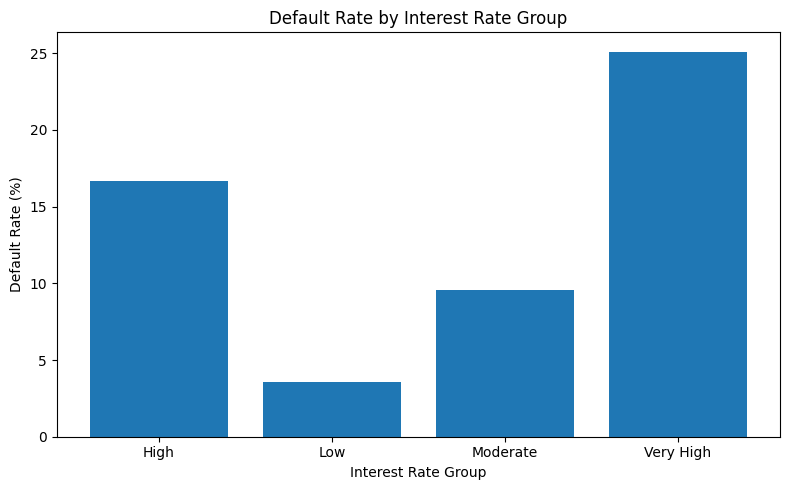

In [30]:
rate_default = (
    df.groupby("interest_rate_group")["default_flag"]
    .mean() * 100
)

plt.figure(figsize=(8,5))

plt.bar(
    rate_default.index.astype(str),
    rate_default.values
)

plt.title("Default Rate by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "../assets/python/default_by_interest_rate.png",
    dpi=300
)

plt.show()

Observation

* Default rates increase with higher interest rate categories.

Business Insight

Higher interest rates are associated with riskier borrowers.

# Geographic Analysis

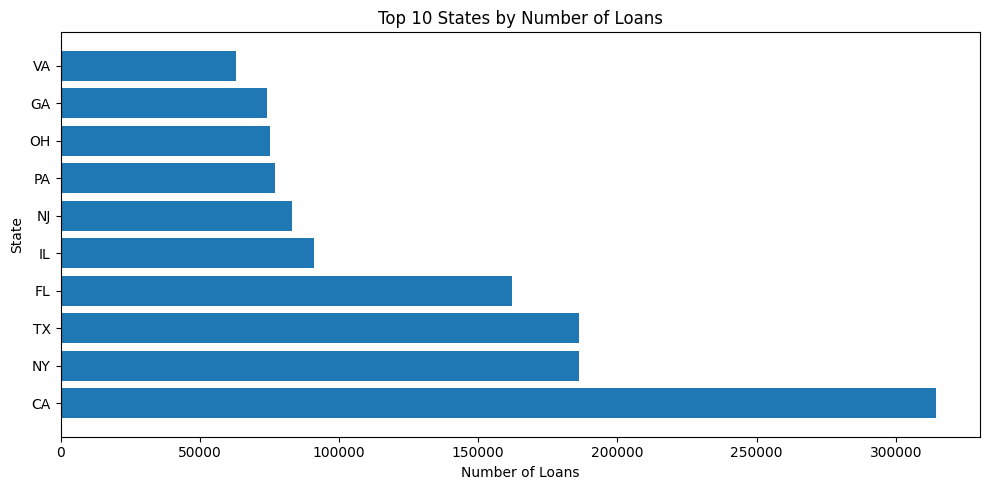

In [31]:
top_states = (
    df["addr_state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_states.index,
    top_states.values
)

plt.title("Top 10 States by Number of Loans")
plt.xlabel("Number of Loans")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../assets/python/top_states_loans.png",
    dpi=300
)

plt.show()

Observation

* A few states account for a significant share of total loans.

Business Insight

The bank’s lending portfolio is concentrated in a limited number of geographic regions.

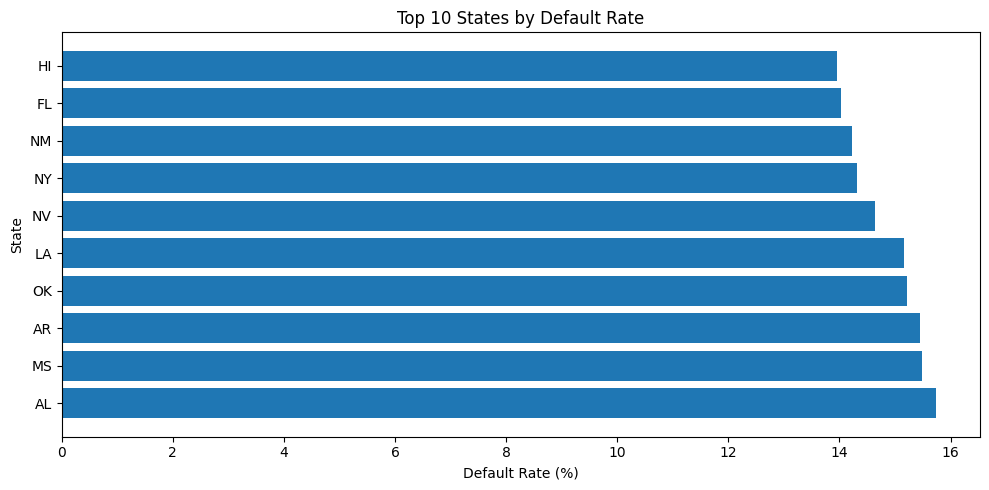

In [32]:
state_default = (
    df.groupby("addr_state")["default_flag"]
    .mean() * 100
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    state_default.index,
    state_default.values
)

plt.title("Top 10 States by Default Rate")
plt.xlabel("Default Rate (%)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../assets/python/top_states_default_rate.png",
    dpi=300
)

plt.show()

Observation

* Default rates differ noticeably between states.

Business Insight

Geographic trends may reflect regional economic conditions and should be considered during portfolio monitoring.

# Time Analysis

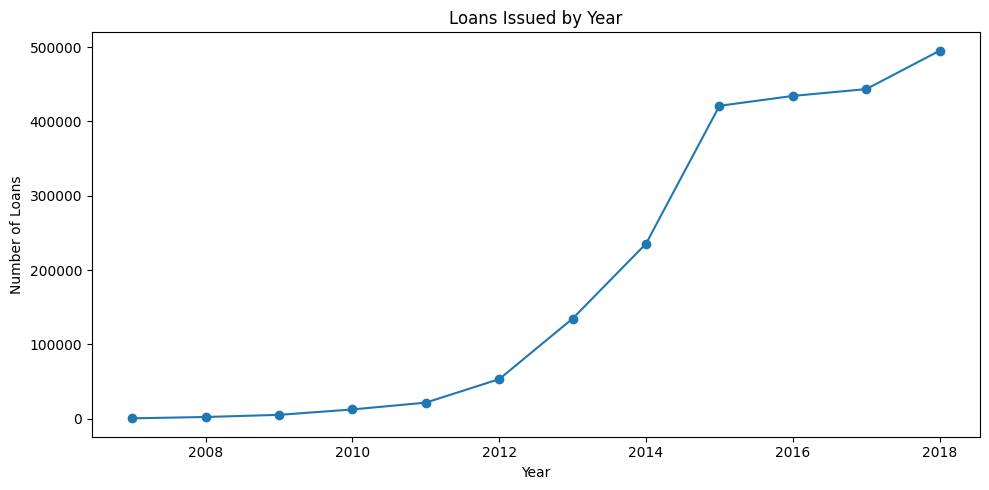

In [33]:
loan_trend = (
    df.groupby("issue_year")
    .size()
)

plt.figure(figsize=(10,5))

plt.plot(
    loan_trend.index,
    loan_trend.values,
    marker="o"
)

plt.title("Loans Issued by Year")
plt.xlabel("Year")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "../assets/python/loan_trend.png",
    dpi=300
)

plt.show()

Observation

* Lending activity changes over the years.
* Some years show significantly higher loan issuance.

Business Insight

Understanding lending trends helps explain portfolio growth and changing business strategy.

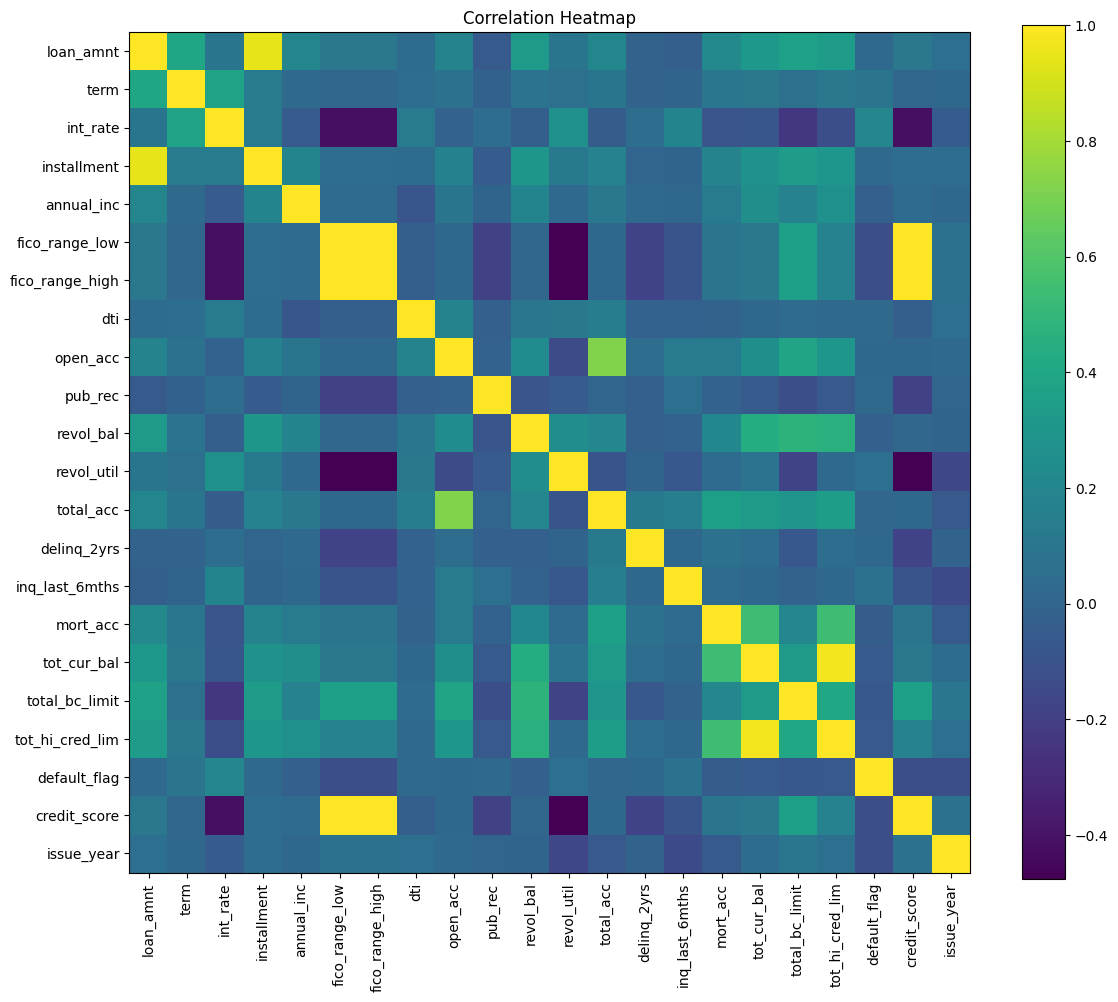

In [34]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../assets/python/correlation_heatmap.png",
    dpi=300
)

plt.show()

Observation

* Some financial variables are strongly correlated.
* Several variables provide complementary information with limited correlation.

Business Insight

Highly correlated variables should be monitored before machine learning to reduce redundancy and improve model interpretability.

⸻

# Key Business Insights

## Portfolio

- The portfolio is dominated by Fully Paid and Current loans.
- Overall default rate is approximately 13%.

## Customer

- Middle-income borrowers represent the largest customer segment.
- Debt consolidation is the most common loan purpose.
- Most borrowers either own a mortgage or rent their homes.

## Risk

- Lower loan grades show substantially higher default rates.
- Higher interest rates are associated with higher default risk.
- Income level and credit score provide useful indicators of borrower risk.

## Geography

- Lending activity is concentrated in a small number of states.
- Default rates vary by state, highlighting regional differences.

## Time

- Loan issuance has changed considerably over time, reflecting shifts in lending activity and market conditions.